In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns
from pandas.api.types import CategoricalDtype
import scipy as sp
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color

In [129]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path

WindowsPath('C:/Users/sofia/Documents/mcgill/brouhardlab/results/2021_WT_R303X_residence/WT_500pM-HUGS_100nM-HUS_100ms_500mspf/2021-06-01_CH2_400pM-WT-HUGS_200nM-WT-HUS/CH2_1.5gauss/1gauss')

In [163]:
spots = pd.read_csv(path/'Spots in tracks statistics.csv', encoding='utf-8')
data = pd.read_csv(path/'Track statistics.csv', encoding='utf-8')

In [164]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
yellow = '#FFCB05'

In [165]:
data

,Label,TRACK_ID,NUMBER_SPOTS,NUMBER_GAPS,LONGEST_GAP,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,TRACK_DURATION,TRACK_START,...,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TRACK_MAX_QUALITY,TRACK_MIN_QUALITY,TRACK_MEDIAN_QUALITY,TRACK_STD_QUALITY
0,Track_32511,0,398,1,3,0,0,0,400,0,...,0.425,1.653,0.001,0.374,0.266,11.219,26.210,4.293,9.536,4.781
1,Track_32512,1,6,0,0,0,0,0,5,0,...,0.820,1.295,0.388,0.855,0.331,9.391,11.523,8.028,9.331,1.240
2,Track_32513,2,80,0,0,0,0,0,79,0,...,0.589,1.507,0.125,0.509,0.311,8.176,15.299,4.339,7.916,2.095
3,Track_32514,3,43,1,1,0,0,0,43,0,...,0.542,1.745,0.094,0.533,0.316,6.721,10.387,4.057,6.410,1.572
4,Track_32515,4,49,3,2,0,0,0,52,0,...,0.689,1.604,0.111,0.596,0.383,8.103,13.287,4.792,7.739,1.806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21832,Track_54343,21832,2,0,0,0,0,0,1,399,...,0.839,0.839,0.839,0.839,NaN,4.429,4.703,4.154,4.703,0.275
21833,Track_54344,21833,2,0,0,0,0,0,1,399,...,0.523,0.523,0.523,0.523,NaN,6.849,7.532,6.166,7.532,0.683
21834,Track_54345,21834,2,0,0,0,0,0,1,399,...,1.264,1.264,1.264,1.264,NaN,9.688,9.741,9.635,9.741,0.053
21835,Track_54346,21835,2,0,0,0,0,0,1,399,...,1.981,1.981,1.981,1.981,NaN,4.478,4.624,4.331,4.624,0.147


In [166]:
def open_roi_line(name):
    roi_path = path/(name)

    roi_data = read_roi_zip(roi_path)
    roi_df = pd.DataFrame(columns=['Track ID','x1','x2','y1','y2'])
    for key in roi_data:
        roi_df = roi_df.append({'Track ID': roi_data[key]['name'],'x1': roi_data[key]['x1'],'x2': roi_data[key]['x2'],'y1': roi_data[key]['y1'],'y2': roi_data[key]['y2']}, ignore_index=True)
    return roi_df

In [167]:
lines = open_roi_line('kymolines.zip')

In [168]:
def mask_dots(lines):
    maskdotsx = []
    maskdotsy = []
    for i in list(lines.index):
        maskdotsx = maskdotsx + list(np.linspace(lines['x1'][i],lines['x2'][i],30))
        maskdotsy = maskdotsy + list(np.linspace(lines['y1'][i],lines['y2'][i],30))
    return maskdotsx,maskdotsy

In [169]:
maskdots = mask_dots(lines)
len(maskdots[0])

2280

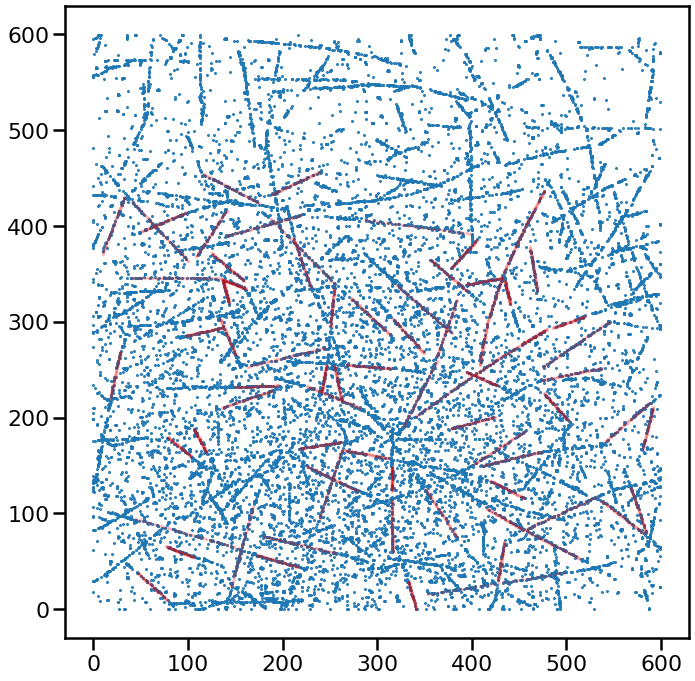

In [170]:
x=data['TRACK_X_LOCATION']
y=data['TRACK_Y_LOCATION']
scattersize = 1
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)
ax.scatter(maskdots[0] , maskdots[1], color=red,s = scattersize*3, alpha=0.2);

In [174]:
i= 0
R = 1.5
xy = data[['TRACK_X_LOCATION','TRACK_Y_LOCATION']]
square = xy[(xy['TRACK_X_LOCATION']<(maskdots[0][i]+R)) & (xy['TRACK_X_LOCATION']>(maskdots[0][i]-R)) 
                    & (xy['TRACK_Y_LOCATION']<(maskdots[1][i]+R)) & (xy['TRACK_Y_LOCATION']>(maskdots[1][i]-R))]
square

,TRACK_X_LOCATION,TRACK_Y_LOCATION
2177,327.986,191.139
14638,327.557,189.549
18365,328.549,190.321


In [175]:
def filter_maskroi(data,maskdots,R):
    
    xy = data[['TRACK_X_LOCATION','TRACK_Y_LOCATION']]
    squareindex = []
    
    for i in np.arange(0,len(maskdots[0])): #

        square = xy[(xy['TRACK_X_LOCATION']<(maskdots[0][i]+R)) & (xy['TRACK_X_LOCATION']>(maskdots[0][i]-R)) 
                    & (xy['TRACK_Y_LOCATION']<(maskdots[1][i]+R)) & (xy['TRACK_Y_LOCATION']>(maskdots[1][i]-R))]
        
        squareindex0 = list(square.index)
        
        squareindex = squareindex + squareindex0
        
    squareindex = list(set(squareindex))
    
    data0 = data[data.index.isin(squareindex)]
        
    return data0

3541


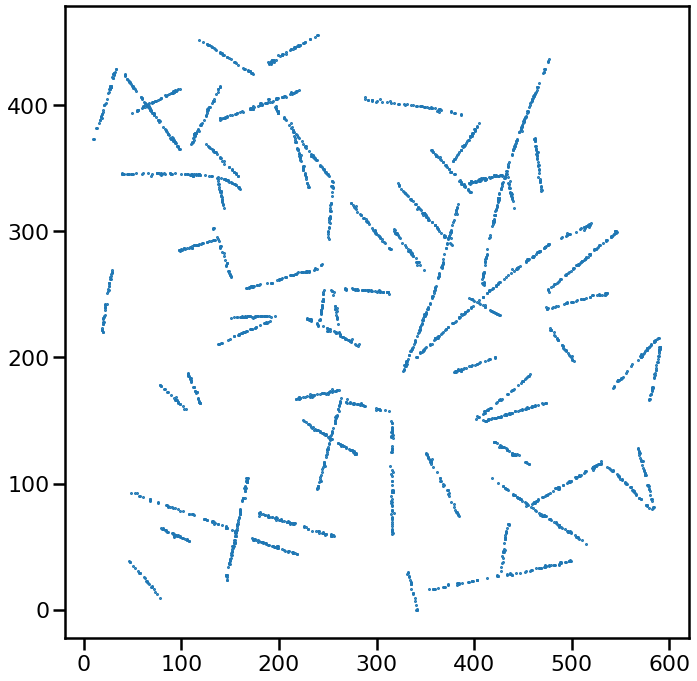

In [176]:
data0 = filter_maskroi(data,maskdots,R)
print(len(data0))
x=data0['TRACK_X_LOCATION']
y=data0['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

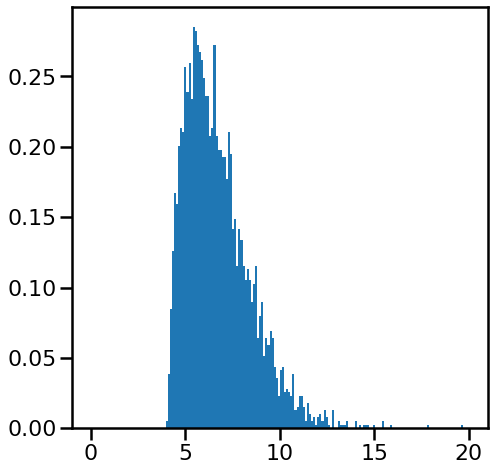

In [177]:
y=data0['TRACK_MEAN_QUALITY']
scattersize = 1
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 20 + 0.11, 0.11), density=True);

In [246]:
min_duration = 10
startstop = 5
lastframe = data['TRACK_STOP'].max()
data1 = data0[(data0['TRACK_START']>=startstop) & (data0['TRACK_STOP']<=(lastframe-startstop)) & (data0['TRACK_DURATION']>=min_duration)]
data1

,Label,TRACK_ID,NUMBER_SPOTS,NUMBER_GAPS,LONGEST_GAP,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,TRACK_DURATION,TRACK_START,...,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TRACK_MAX_QUALITY,TRACK_MIN_QUALITY,TRACK_MEDIAN_QUALITY,TRACK_STD_QUALITY
949,Track_33460,949,13,0,0,0,0,0,12,5,...,0.840,2.480,0.387,0.713,0.549,7.166,9.534,5.031,7.347,1.483
957,Track_33468,957,53,3,1,0,0,0,55,5,...,0.525,1.370,0.042,0.451,0.329,8.829,14.067,4.825,9.095,1.856
970,Track_33481,970,9,3,4,0,0,0,15,5,...,0.479,1.091,0.060,0.616,0.373,5.992,8.653,4.722,5.442,1.317
978,Track_33489,978,22,3,1,0,0,0,24,5,...,0.567,1.384,0.200,0.405,0.320,7.306,12.474,5.232,6.980,1.715
1012,Track_33523,1012,36,1,1,0,0,0,36,6,...,0.550,1.529,0.102,0.497,0.347,9.904,15.406,4.478,9.703,2.561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20750,Track_53261,20750,17,1,2,0,0,0,18,377,...,0.563,1.235,0.117,0.570,0.275,5.451,7.908,4.037,4.727,1.260
20789,Track_53300,20789,12,0,0,0,0,0,11,378,...,0.640,1.495,0.146,0.508,0.508,7.641,10.322,5.101,8.205,1.964
20837,Track_53348,20837,14,0,0,0,0,0,13,379,...,0.780,1.349,0.154,0.860,0.360,7.846,12.128,5.320,7.644,1.700
21027,Track_53538,21027,11,0,0,0,0,0,10,384,...,0.441,1.122,0.047,0.346,0.357,7.782,11.274,4.821,7.776,1.903


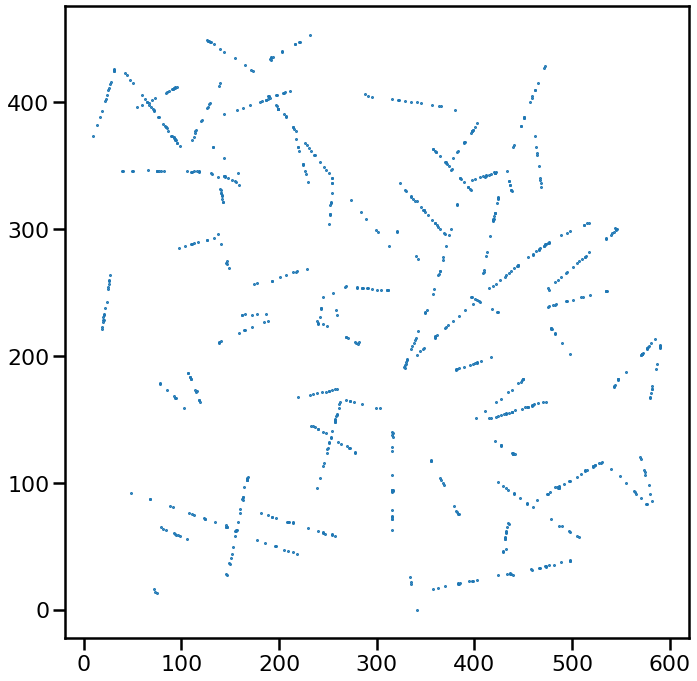

In [247]:
x=data1['TRACK_X_LOCATION']
y=data1['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

In [248]:
def filter_neighbors(data0,R,N,iterations):
    
    for k in range(iterations):
        xy = data0[['TRACK_X_LOCATION','TRACK_Y_LOCATION']]
        for i in list(xy.index): #

            xyvalue = xy.loc[i].values
            xvalue = xyvalue[0]
            yvalue = xyvalue[1]

            square = xy[(xy['TRACK_X_LOCATION']<(xvalue+R)) & (xy['TRACK_X_LOCATION']>(xvalue-R)) & (xy['TRACK_Y_LOCATION']<(yvalue+R)) & (xy['TRACK_Y_LOCATION']>(yvalue-R))]

            if (len(square) < N):
                try:
                    data0 = data0.drop(square.index)
                except KeyError:
                     continue

    return data0

In [249]:
# data1 = filter_neighbors(data0,10,2,1)

# x=data1['TRACK_X_LOCATION']
# y=data1['TRACK_Y_LOCATION']
# fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
# ax.scatter(x , y , s = scattersize)

## Spots ##

In [250]:
spots

,Label,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,...,MANUAL_COLOR,MEAN_INTENSITY,MEDIAN_INTENSITY,MIN_INTENSITY,MAX_INTENSITY,TOTAL_INTENSITY,STANDARD_DEVIATION,ESTIMATED_DIAMETER,CONTRAST,SNR
0,ID9361224,9361224,0,26.210,504.251,299.909,0,0,0,2.5,...,-10921639,225.486,226,188,274,8343,24.273,4.411,0.086,1.464
1,ID9359502,9359502,0,19.766,504.413,300.029,0,1,1,2.5,...,-10921639,213.378,210,187,248,7895,17.166,4.413,0.070,1.622
2,ID9358632,9358632,0,23.855,504.394,299.704,0,2,2,2.5,...,-10921639,220.351,218,184,266,8153,22.986,4.409,0.081,1.435
3,ID9360361,9360361,0,22.108,504.480,299.879,0,3,3,2.5,...,-10921639,215.622,213,183,259,7978,21.790,4.411,0.074,1.361
4,ID9362906,9362906,0,25.843,504.437,299.794,0,4,4,2.5,...,-10921639,221.270,217,184,276,8187,26.350,4.409,0.086,1.331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172925,ID9592195,9592195,21834,9.635,340.298,400.133,0,400,400,2.5,...,-10921639,193.000,192,174,211,7141,9.107,4.400,0.036,1.474
172926,ID9592702,9592702,21835,4.624,181.189,402.457,0,399,399,2.5,...,-10921639,176.649,176,167,187,6536,5.149,4.403,0.019,1.309
172927,ID9592196,9592196,21835,4.331,181.860,400.593,0,400,400,2.5,...,-10921639,180.784,180,173,189,6689,4.124,4.386,0.018,1.559
172928,ID9592673,9592673,21836,4.014,152.799,370.133,0,399,399,2.5,...,-10921639,176.703,176,169,185,6538,4.189,4.394,0.015,1.277


In [251]:
trackID = data1['TRACK_ID']
filteredspots = spots[spots['TRACK_ID'].isin(trackID)]

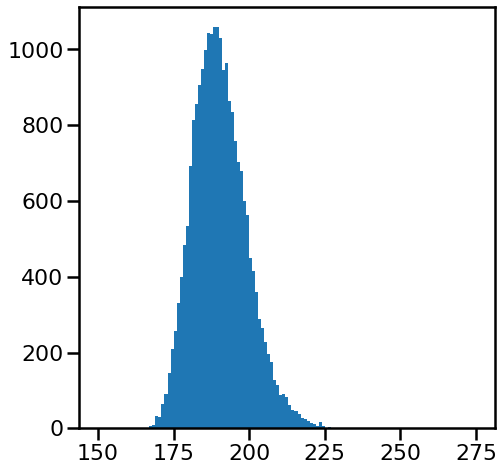

In [252]:
y=filteredspots['MEAN_INTENSITY']
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(150, 275 + 1, 1));

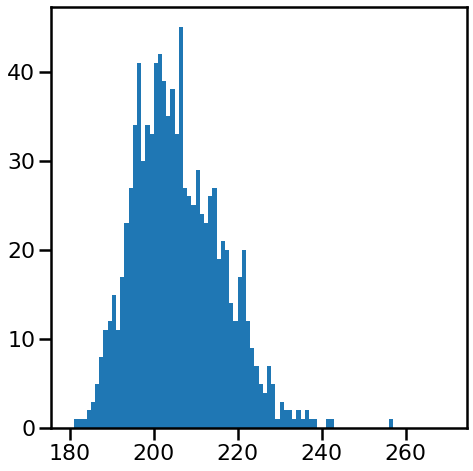

In [253]:
meantrackspots =filteredspots.groupby('TRACK_ID').mean()
y = meantrackspots['MAX_INTENSITY']
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(180, 270 + 1, 1));

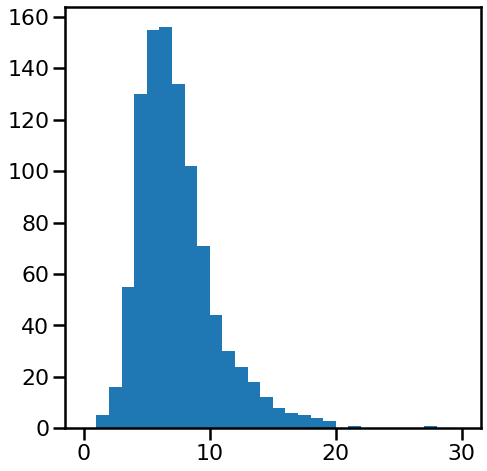

In [254]:
stdtrackspots =filteredspots.groupby('TRACK_ID').std()
y = stdtrackspots['MAX_INTENSITY']
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 30 + 1, 1));

In [255]:
meantrackspots[(meantrackspots['MAX_INTENSITY'] < 210) | (meantrackspots['MAX_INTENSITY'] > 230)]

,ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_COLOR,MEAN_INTENSITY,MEDIAN_INTENSITY,MIN_INTENSITY,MAX_INTENSITY,TOTAL_INTENSITY,STANDARD_DEVIATION,ESTIMATED_DIAMETER,CONTRAST,SNR
TRACK_ID,,,,,,,,,,,,,,,,,,,
970,9.368591e+06,5.992111,504.767778,104.832667,0.0,12.333333,12.333333,2.5,1.0,-10921639.0,189.036000,188.555556,175.444444,203.666667,6994.333333,7.184333,2.803333,0.019889,1.007111
978,9.372313e+06,7.305909,468.194136,336.142364,0.0,16.363636,16.363636,2.5,1.0,-10921639.0,186.563818,185.454545,174.136364,203.409091,6902.863636,7.798318,4.243909,0.026682,1.241773
1024,9.367871e+06,11.294909,140.220545,288.082000,0.0,11.000000,11.000000,2.5,1.0,-10921639.0,207.240818,205.090909,189.909091,232.363636,7667.909091,11.345000,3.969636,0.037727,1.334182
1098,9.368351e+06,12.786455,315.952273,137.549273,0.0,12.000000,12.000000,2.5,1.0,-10921639.0,216.142455,213.545455,196.000000,242.000000,7997.272727,12.586000,4.410909,0.041818,1.396727
1143,9.371855e+06,10.686412,271.093706,213.729824,0.0,16.000000,16.000000,2.5,1.0,-10921639.0,209.225706,206.588235,191.705882,235.000000,7741.352941,11.536765,3.557882,0.034059,1.154235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20750,9.585318e+06,5.451471,586.770882,193.855647,0.0,385.588235,385.588235,2.5,1.0,-10921639.0,171.341941,170.470588,161.470588,183.764706,6339.647059,6.050882,3.698765,0.021059,1.165000
20789,9.584363e+06,7.640750,440.738500,366.207583,0.0,383.500000,383.500000,2.5,1.0,-10921639.0,182.619333,182.166667,170.333333,196.333333,6756.916667,7.063500,4.207083,0.029583,1.480583
20837,9.585043e+06,7.846214,151.746071,43.546643,0.0,385.500000,385.500000,2.5,1.0,-10921639.0,190.803214,189.500000,178.571429,207.214286,7059.714286,7.896357,3.891500,0.029286,1.385429


469


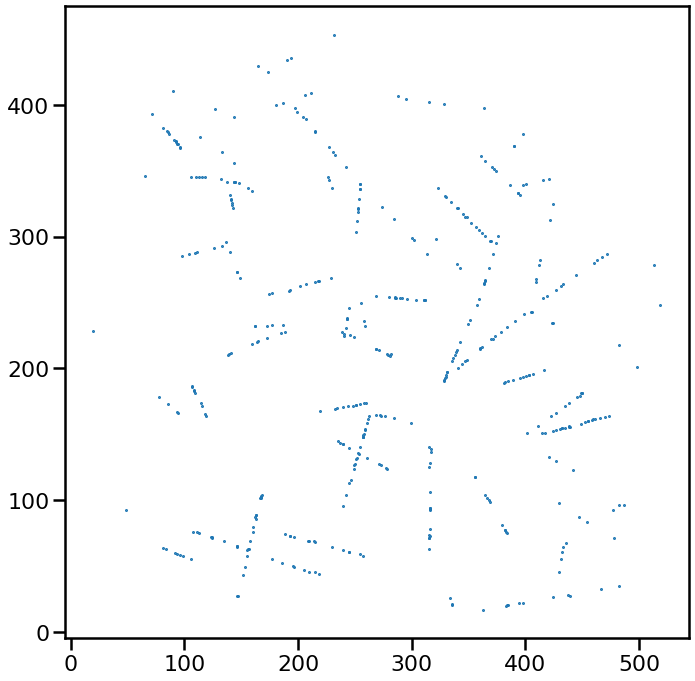

In [256]:
brightspotsID = meantrackspots[(meantrackspots['MAX_INTENSITY'] < 205) | (meantrackspots['MAX_INTENSITY'] > 235)].index.values
data2 = data1[~data1['TRACK_ID'].isin(brightspotsID)]
print(len(data2))

x=data2['TRACK_X_LOCATION']
y=data2['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*1.5,7.75*1.5))
ax.scatter(x , y , s = scattersize)

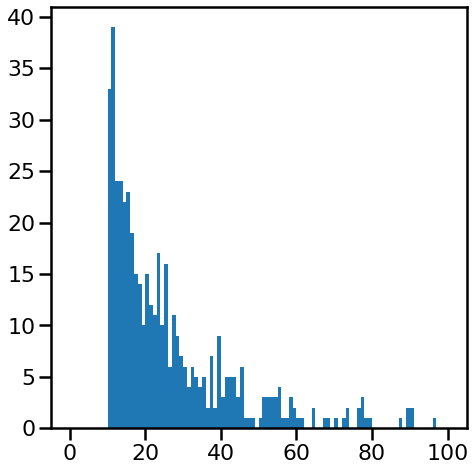

In [257]:
y=data2['TRACK_DURATION']
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 100 + 1, 1));

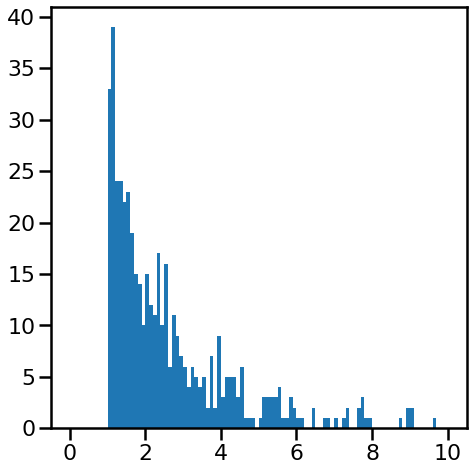

In [258]:
track_duration=data2['TRACK_DURATION']*0.1
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(track_duration, bins=np.arange(0, 10 + 0.1, 0.1));

## Exponential Fit ##

In [259]:
def exponential(x, scale):
    return ((np.exp(-x/scale) )/(scale))

def equation_fit(track_duration,x):
    
    equation = exponential
        
    results = pd.DataFrame(columns=[] , index=[])
    
    n, bins, patches = ax.hist(track_duration, bins=x, density=True);
                
    coeff, var_matrix = sp.optimize.curve_fit(equation,bins[:-1],n)

    variance = np.diagonal(var_matrix) #Refer [3]
    SE = np.sqrt(variance) #Refer [4]

            #======Making a data frame========
    results0 = pd.DataFrame(columns=[] , index=[])
    
    for k in np.arange(0,len(coeff)):
        header = [np.array(['Exponential']),np.array(['Coefficient '+ str(k)])]
        r0 = pd.DataFrame([coeff[k],SE[k]], index=(['Value','SE']),columns= header)
        results0 = pd.concat([results0, r0], axis=1, sort=False)

    results = pd.concat([results, results0], sort=False)

    return results


In [260]:
spf = 0.1
DCXconc=str(200)
DCXType = 'WT'
xlim = 10
bins = 0.1

x = np.arange(min_duration*spf, xlim + bins, bins)

shift = min_duration*spf

track_duration_shift=(track_duration.add(-shift)) #times 100ms
EqFit = equation_fit(track_duration,x)

#EqFit.loc['Value'] = EqFit.loc['Value'].add((min_duration-1)*spf)

scale = EqFit['Exponential']['Coefficient 0'].loc['Value']
#x0 = EqFit['Exponential']['Coefficient 1'].loc['Value']
EqFit

,Exponential
,Coefficient 0
Value,1.516269
SE,0.369131


In [261]:
true_scale = EqFit['Exponential']['Coefficient 0'].loc['Value']+((min_duration)*spf)
SE = EqFit['Exponential']['Coefficient 0'].loc['SE']
scalestr = str(round(true_scale,2))
SEstr = str(round(SE,3))
scalestr,SEstr

('2.52', '0.369')

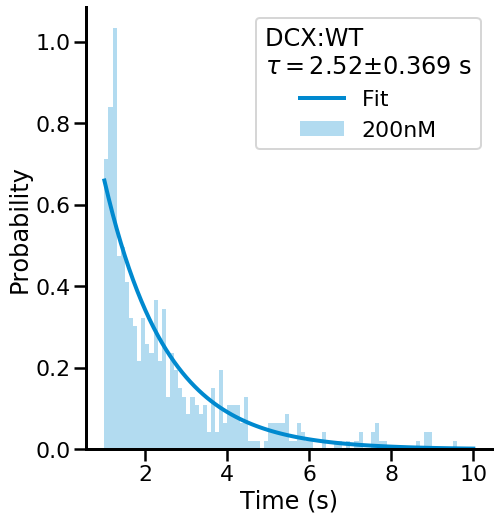

In [262]:
color=cyan

fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(track_duration, bins=x, density=True,color = color,alpha = 0.3);
ax.plot(x,exponential(x-shift,scale),color = color, lw=4);
ax.set_xlabel('Time (s)')
ax.set_ylabel('Probability')
#ax.set_ylim(0,1.2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)

ax.legend(('Fit',DCXconc + 'nM'),loc='upper right',title='DCX:' + DCXType +' \n' r'$\tau = $' + scalestr + r'$\pm $'  + SEstr + ' s')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()
plt.savefig(path/('track-duration_expo-fit.pdf'))